# FT-Transformer Class Prediction Model

This model categorizes the performace of players in the following way:
- If their next game gamescore is less than 65% of their previous average, their score is categorized in class 0.
- If their next game gamescore is between 65% and 145% of their previous average, their score is categorized in class 1.
- If their next game gamescore is greater than 145% of their previous average, their score is categorized in class 2.

### How to add more features: 
To add more features, the following lines must be changed:
- dtype = np.dtype([...]): for each added feature, add ('feature name', datatype)
- data = np.loadtxt(...): usecols=(...) determines what columns (0-indexed) are used for training. Add the column number of the recently-added feature to the end of the list
- emotion_fields = [...]: add 'feature name' to the list

Class distribution in full dataset:
  Class 0: 132 samples (22.1%)
  Class 1: 344 samples (57.7%)
  Class 2: 120 samples (20.1%)

Class 0 threshold: < 0.65x historical avg
Class 1 threshold: 0.65x - 1.45x historical avg
Class 2 threshold: > 1.45x historical avg
Computed class weights:
  Class 0: 1.4424
  Class 1: 0.5877
  Class 2: 1.6528
Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - loss: 0.5472 - sparse_categorical_accuracy: 0.4118 - val_loss: 0.4920 - val_sparse_categorical_accuracy: 0.3167
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.5135 - sparse_categorical_accuracy: 0.3277 - val_loss: 0.4823 - val_sparse_categorical_accuracy: 0.5417
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.4961 - sparse_categorical_accuracy: 0.3235 - val_loss: 0.4786 - val_sparse_categorical_accuracy: 0.1583
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.4876 - sparse_categorical_accuracy: 0.3004 - val_loss: 0.4745 - val_sparse_categorical_accuracy: 0.

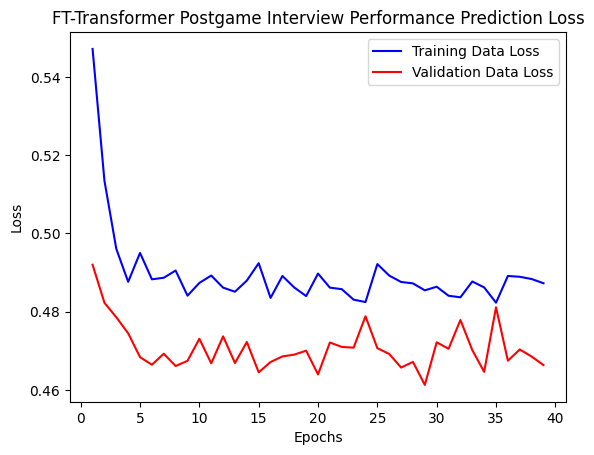

('dQj-sfEhw_', 0.004482, 0.000104, 0.012901000000000001, 0.0017100000000000001, 0.028845, 0.000325, 0.9516330000000001, 0.2710017574692443, 2.0)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf

# Load the same dataset as the MLP notebook.
# This FT-Transformer version predicts next_game_gmsc as a regression target.
data_file = 'emotion_results_final_with_gmsc.csv'
dtype = np.dtype([
    ('id', 'U10'),
    ('avg_angry', float),
    ('avg_disgust', float),
    ('avg_fear', float),
    ('avg_happy', float),
    ('avg_sad', float),
    ('avg_surprise', float),
    ('avg_neutral', float),
    ('historical_gmsc_avg', float),
    ('next_game_gmsc', float),
])

data = np.loadtxt(
    data_file,
    dtype=dtype,
    delimiter=',',
    skiprows=1,
    usecols=(2, 4, 5, 6, 7, 8, 9, 10, 13, 14),
)

emotion_fields = [
    'avg_angry',
    'avg_disgust',
    'avg_fear',
    'avg_happy',
    'avg_sad',
    'avg_surprise',
    'avg_neutral',
]
for field in emotion_fields:
    data[field] = data[field] / 100.0

# split next_game_gmsc into 3 classes based on distribution:
# 0 if next_game_gmsc is less than 75% of historical_gmsc_avg
# 1 if next_game_gmsc is between 75% and 125% of historical_gmsc_avg
# 2 if next_game_gmsc is greater than 125% of historical_gmsc_avg
data['next_game_gmsc'] = np.where(
    data['next_game_gmsc'] < 0.65 * data['historical_gmsc_avg'], 0,
    np.where(
        data['next_game_gmsc'] > 1.45 * data['historical_gmsc_avg'], 2, 1
    )
)

data['historical_gmsc_avg'] = data['historical_gmsc_avg'] / np.max(data['historical_gmsc_avg'])

# write data to new csv file for testing
np.savetxt('test_data.csv', data, delimiter=',', fmt='%s', header=','.join(data.dtype.names), comments='')

np.random.shuffle(data)

split_index = int(len(data) * 0.8)
train_data = data[:split_index]
test_data = data[split_index:]

feature_names = data.dtype.names[1:-1]
x_train = np.array([train_data[name] for name in feature_names]).T.astype('float32')
y_train = np.array(train_data['next_game_gmsc']).astype('float32')
x_test = np.array([test_data[name] for name in feature_names]).T.astype('float32')
y_test = np.array(test_data['next_game_gmsc']).astype('float32')

# Standardize features using the training split only.
feature_mean = x_train.mean(axis=0, keepdims=True)
feature_std = x_train.std(axis=0, keepdims=True) + 1e-8
x_train = (x_train - feature_mean) / feature_std
x_test = (x_test - feature_mean) / feature_std

# FT-Transformer treats each feature as a token.
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

# Check class distribution BEFORE splitting train/test
unique, counts = np.unique(data['next_game_gmsc'].astype(int), return_counts=True)
print("Class distribution in full dataset:")
for cls, count in zip(unique, counts):
    print(f"  Class {int(cls)}: {count} samples ({100*count/len(data):.1f}%)")

# Also check your threshold boundaries
print(f"\nClass 0 threshold: < {0.65:.2f}x historical avg")
print(f"Class 1 threshold: {0.65:.2f}x - {1.45:.2f}x historical avg")
print(f"Class 2 threshold: > {1.45:.2f}x historical avg")

def transformer_block(inputs, embed_dim, num_heads, ff_dim, dropout_rate=0.1):
    attention_input = layers.LayerNormalization(epsilon=1e-6)(inputs)
    attention_output = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=embed_dim // num_heads,
        dropout=dropout_rate,
    )(attention_input, attention_input)
    x = layers.Add()([inputs, attention_output])

    ffn_input = layers.LayerNormalization(epsilon=1e-6)(x)
    ffn_output = layers.Dense(ff_dim, activation='relu')(ffn_input)
    ffn_output = layers.Dropout(dropout_rate)(ffn_output)
    ffn_output = layers.Dense(embed_dim)(ffn_output)
    return layers.Add()([x, ffn_output])


embed_dim = 32
num_heads = 4
ff_dim = 64

inputs = layers.Input(shape=(x_train.shape[1], 1))
x = layers.Dense(embed_dim)(inputs)
x = layers.Dropout(0.1)(x)
x = transformer_block(x, embed_dim, num_heads, ff_dim, dropout_rate=0.1)
x = transformer_block(x, embed_dim, num_heads, ff_dim, dropout_rate=0.1)
x = layers.LayerNormalization(epsilon=1e-6)(x)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(32, activation='relu')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(3, activation='softmax')(x)

model = keras.Model(inputs, outputs, name='ft_transformer_classifier')

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train.astype(int)),
    y=y_train.astype(int),
)

print("Computed class weights:")
for i, w in enumerate(class_weights):
    print(f"  Class {i}: {w:.4f}")

class_weights_dict = {i: w for i, w in enumerate(class_weights)}

def make_weighted_focal_loss(class_weights, gamma=2.0):
    class_weights_tensor = tf.constant(class_weights, dtype=tf.float32)

    def weighted_focal_loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_true_one_hot = tf.one_hot(y_true, depth=3)

        # Prevent log(0)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        # Cross-entropy on probabilities
        ce = -tf.reduce_sum(y_true_one_hot * tf.math.log(y_pred), axis=-1)

        # Probability assigned to the true class
        p_t = tf.reduce_sum(y_true_one_hot * y_pred, axis=-1)

        # Weight for the true class
        alpha_t = tf.reduce_sum(y_true_one_hot * class_weights_tensor, axis=-1)

        focal = alpha_t * tf.pow(1.0 - p_t, gamma) * ce
        return tf.reduce_mean(focal)

    return weighted_focal_loss

loss_fn = make_weighted_focal_loss(class_weights, gamma=2.0)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=loss_fn,
    metrics=['sparse_categorical_accuracy'],
)

history = model.fit(
    x_train,
    y_train,
    validation_data=(x_test, y_test),
    epochs=100,
    batch_size=16,
    callbacks=[keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)],
    verbose=1,
)

loss = history.history['loss']
val_loss = history.history['val_loss']
actual_epochs = range(1, len(loss) + 1)

plt.plot(actual_epochs, loss, 'b-', label='Training Data Loss')
plt.plot(actual_epochs, val_loss, 'r-', label='Validation Data Loss')
plt.title('FT-Transformer Postgame Interview Performance Prediction Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

print(data[0])


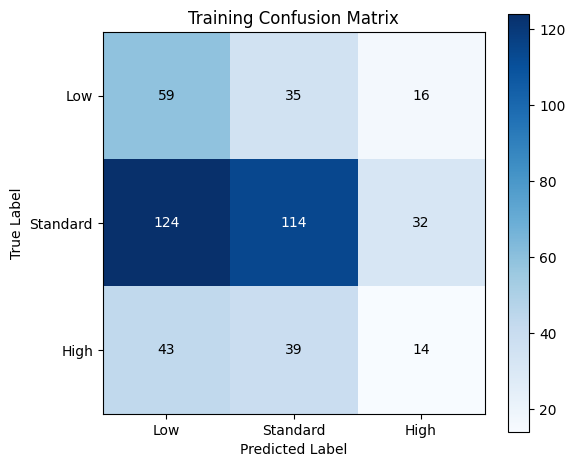

In [3]:
train_probs = model.predict(x_train, verbose=0)
train_pred = np.argmax(train_probs, axis=1)
train_true = y_train.astype(int)

cm = tf.math.confusion_matrix(train_true, train_pred, num_classes=3).numpy()
class_labels = ['Low', 'Standard', 'High']

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Training Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(class_labels))
plt.xticks(tick_marks, class_labels)
plt.yticks(tick_marks, class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

threshold = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            format(cm[i, j], 'd'),
            ha='center',
            va='center',
            color='white' if cm[i, j] > threshold else 'black',
        )

plt.tight_layout()
plt.show()


## AI explanation of FT Transformer steps

In ft_transformer_model.ipynb, the model is basically turning tabular features into a small token sequence, then using attention to learn how those features interact.

**Layer-by-layer**

- `Input(shape=(x_train.shape[1], 1))`  
  This says each sample is a list of feature tokens, one token per feature. For your data, each emotion/stat feature becomes its own position. This is better than flattening everything immediately because it keeps feature identity visible to the model.

- `Dense(embed_dim)`  
  This projects each 1-value feature token into a richer vector space of size 32. That helps because raw numeric values alone are too limited; the dense projection gives the transformer a learned representation to work with.

- `Dropout(0.1)`  
  This randomly drops some activations during training. It reduces overfitting, which is important here because tabular datasets are usually not huge.

- `transformer_block(...)`  
  This is the main performance improvement over a plain MLP.

  - `LayerNormalization` before attention  
    Normalizes each token’s representation so training is more stable and gradients behave better.

  - `MultiHeadAttention(...)`  
    This is the key part. It lets each feature look at every other feature and learn relationships like “high anger plus low historical performance” or “surprise plus neutral tone.”  
    Multiple heads help the model learn several different kinds of interactions at once instead of forcing one representation to do everything.

  - `Add()` residual connection after attention  
    This preserves the original input signal and makes optimization easier. It helps the model learn “adjustments” to the input rather than having to rebuild everything from scratch.

  - Second `LayerNormalization`  
    Again stabilizes training before the feed-forward part.

  - `Dense(ff_dim, activation='relu')`  
    This is the feed-forward layer inside the transformer block. It transforms the attended features into a higher-level nonlinear representation.

  - `Dropout(dropout_rate)`  
    Regularizes the feed-forward part so it does not memorize the training set.

  - `Dense(embed_dim)`  
    Brings the representation back to the embedding width so the residual connection can be added cleanly.

  - Second `Add()` residual connection  
    Keeps information flowing through the network and helps deeper training work better.

- Second `transformer_block(...)`  
  Stacking two blocks lets the model learn interactions in layers. The first block can learn basic feature relations, and the second can combine those relations into more abstract patterns.

- `LayerNormalization(epsilon=1e-6)`  
  Stabilizes the final feature representation before pooling.

- `GlobalAveragePooling1D()`  
  Collapses the token sequence into one vector by averaging over features. This turns the transformer output into a fixed-size summary of the whole row. It helps because the model now has a single representation of the entire game/interview feature set.

- `Dense(32, activation='relu')`  
  A final small dense layer mixes the pooled representation and prepares it for prediction. It adds a last nonlinear step before output.

- `Dropout(0.2)`  
  More regularization before the final prediction layer.

- `Dense(1)`  
  The output layer for regression. It predicts one numeric value: the standardized `next_game_gmsc`.

**Why this can outperform the MLP**

A plain MLP treats the row as just a flat vector. The FT-Transformer can explicitly model feature-to-feature interactions through attention, which is useful when the effect of one feature depends on another. That is often the case for emotion data and performance data.

The biggest practical gains usually come from:
- better interaction modeling,
- residual connections that make optimization easier,
- normalization that stabilizes training,
- and regularization that reduces overfitting.

### Additional AI-recommended implementations

Focal Loss: 
- Focal loss is a form of loss calculation that emphasizes calculated loss for harder-to-classify examples.